In [2]:
import xarray as xr

In [28]:
ds_cm4 = xr.open_zarr(
    "/pscratch/sd/s/suryad/data/cm4_piControl_ocean_200yr_full_chunked.zarr"
)

In [7]:
ds_om4 = xr.open_zarr("/global/cfs/cdirs/m4874/suryad/data/OM4_5daily_v0.2.1.zarr")

In [8]:
ds_om4

<xarray.Dataset> Size: 98GB
Dimensions:         (y: 180, x: 360, lev: 19, time: 4745, y_b: 181, x_b: 361)
Coordinates:
    areacello       (y, x) float64 518kB dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz              (lev) int64 152B dask.array<chunksize=(19,), meta=np.ndarray>
    lat             (y, x) float64 518kB dask.array<chunksize=(90, 360), meta=np.ndarray>
    lat_b           (y_b, x_b) float64 523kB dask.array<chunksize=(91, 361), meta=np.ndarray>
  * lev             (lev) float64 152B 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
    lon             (y, x) float64 518kB dask.array<chunksize=(90, 360), meta=np.ndarray>
    lon_b           (y_b, x_b) float64 523kB dask.array<chunksize=(91, 361), meta=np.ndarray>
    ocean_fraction  (lev, y, x) float64 10MB dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
  * time            (time) object 38kB 1958-01-03 12:00:00 ... 2022-12-29 12:...
    wetmask         (lev, y, x) bool 1MB dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
  * x               (x) float64 3kB 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
  * y               (y) float64 1kB -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
Dimensions without coordinates: y_b, x_b
Data variables:
    hfds            (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so              (time, lev, y, x) float32 23GB dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    tauuo           (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    tauvo           (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    thetao          (time, lev, y, x) float32 23GB dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    uo              (time, lev, y, x) float32 23GB dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    vo              (time, lev, y, x) float32 23GB dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    zos             (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    m2lines/ocean-emulators_git_hash:  https://github.com/m2lines/ocean_emula...
    regrid_method:                     conservative

In [29]:
ds_om4.lon.values

array([[  0.5,   1.5,   2.5, ..., 357.5, 358.5, 359.5],
       [  0.5,   1.5,   2.5, ..., 357.5, 358.5, 359.5],
       [  0.5,   1.5,   2.5, ..., 357.5, 358.5, 359.5],
       ...,
       [  0.5,   1.5,   2.5, ..., 357.5, 358.5, 359.5],
       [  0.5,   1.5,   2.5, ..., 357.5, 358.5, 359.5],
       [  0.5,   1.5,   2.5, ..., 357.5, 358.5, 359.5]])

In [34]:
ds_om4.lat.values

array([[-89.23664167, -89.23664167, -89.23664167, ..., -89.23664167,
        -89.23664167, -89.23664167],
       [-88.24777411, -88.24777411, -88.24777411, ..., -88.24777411,
        -88.24777411, -88.24777411],
       [-87.25306675, -87.25306675, -87.25306675, ..., -87.25306675,
        -87.25306675, -87.25306675],
       ...,
       [ 87.25306675,  87.25306675,  87.25306675, ...,  87.25306675,
         87.25306675,  87.25306675],
       [ 88.24777411,  88.24777411,  88.24777411, ...,  88.24777411,
         88.24777411,  88.24777411],
       [ 89.23664167,  89.23664167,  89.23664167, ...,  89.23664167,
         89.23664167,  89.23664167]])

In [38]:
ds_om4.lat

<xarray.DataArray 'lat' (y: 180, x: 360)> Size: 518kB
dask.array<open_dataset-lat, shape=(180, 360), dtype=float64, chunksize=(90, 360), chunktype=numpy.ndarray>
Coordinates:
    areacello  (y, x) float64 518kB dask.array<chunksize=(90, 360), meta=np.ndarray>
    lat        (y, x) float64 518kB dask.array<chunksize=(90, 360), meta=np.ndarray>
    lon        (y, x) float64 518kB dask.array<chunksize=(90, 360), meta=np.ndarray>
  * x          (x) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * y          (y) float64 1kB -89.24 -88.25 -87.25 -86.26 ... 87.25 88.25 89.24
Attributes:
    long_name:  Latitude cell midpoint
    units:      degrees

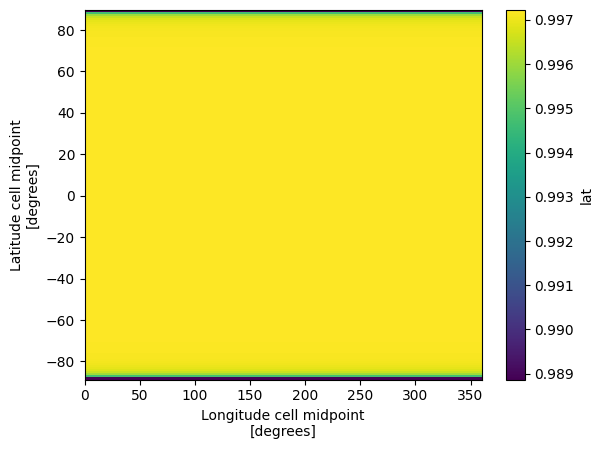

In [51]:
ds_om4.lat.diff(dim="y").plot()

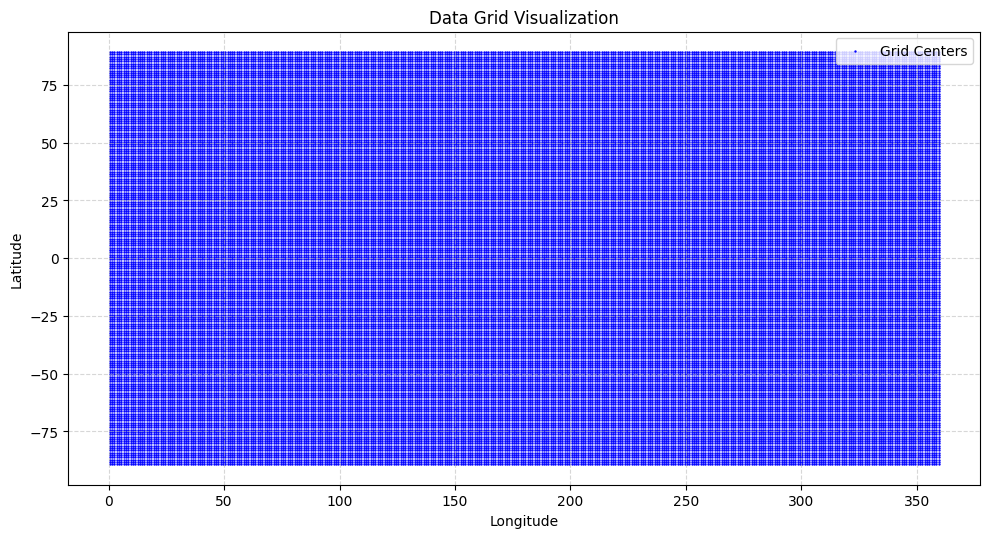

In [31]:
import matplotlib.pyplot as plt

ds = ds_om4
# Assume 'ds' is your xarray.Dataset
fig, ax = plt.subplots(figsize=(10, 6))

# Plot grid cell centers
ax.scatter(ds.lon.values, ds.lat.values, s=0.5, color="blue", label="Grid Centers")

# Plot grid boundaries
# ax.plot(ds.lon_b.values, ds.lat_b.values, color='gray', linewidth=0.3, alpha=0.6)
# ax.plot(ds.lon_b.values.T, ds.lat_b.values.T, color='gray', linewidth=0.3, alpha=0.6)

# Formatting
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Data Grid Visualization")
ax.legend()
ax.set_aspect("equal", adjustable="box")

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

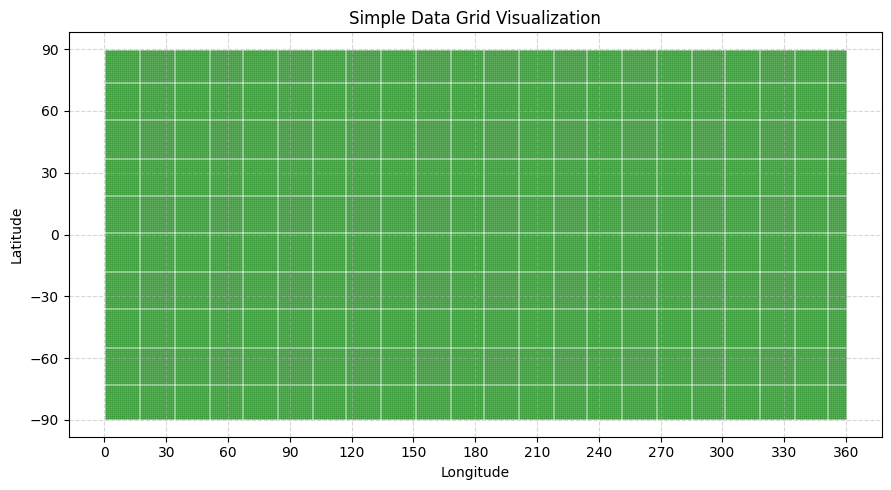

In [32]:
import matplotlib.pyplot as plt
import numpy as np

ds = ds_cm4
# Assume 'ds' is your xarray.Dataset
fig, ax = plt.subplots(figsize=(10, 5))

# Create meshgrid from lon and lat
lon_grid, lat_grid = np.meshgrid(ds.lon, ds.lat)

# Plot grid points
ax.scatter(lon_grid, lat_grid, s=1, color="green", alpha=0.5)

# Enhance visibility with grid lines
ax.set_xticks(np.arange(0, 361, 30))
ax.set_yticks(np.arange(-90, 91, 30))
ax.grid(True, linestyle="--", alpha=0.5)

# Formatting
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Simple Data Grid Visualization")
ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

In [43]:
import fsspec

fs_osn = fsspec.filesystem(
    "s3",
    profile="ocean_emulator_write",  ## This is the profile name you configured above.
)

In [55]:
fs_osn.ls("emulators/jbusecke/ocean-emulators/")

['emulators/jbusecke/ocean-emulators/CM4_5daily_v0.4.0.zarr',
 'emulators/jbusecke/ocean-emulators/CMIP6_CESM2.piControl.r1i1p1f1_v0.1.zarr',
 'emulators/jbusecke/ocean-emulators/CMIP6_GFDL-CM4.piControl.r1i1p1f1_v0.1.zarr',
 'emulators/jbusecke/ocean-emulators/OM4_5daily_v0.2.1.zarr',
 'emulators/jbusecke/ocean-emulators/OM4_5daily_v0.2.zarr']

In [56]:
mapper = fs_osn.get_mapper("emulators/jbusecke/ocean-emulators/CM4_5daily_v0.4.0.zarr")

In [57]:
import xarray as xr

ds = xr.open_zarr(mapper, consolidated=True)
ds

<xarray.Dataset> Size: 303GB
Dimensions:         (y: 180, x: 360, lev: 19, time: 14600, y_b: 181, x_b: 361)
Coordinates:
    areacello       (y, x) float64 518kB dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz              (lev) int64 152B dask.array<chunksize=(19,), meta=np.ndarray>
    lat             (y, x) float64 518kB dask.array<chunksize=(90, 360), meta=np.ndarray>
  * lev             (lev) float64 152B 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
    lon             (y, x) float64 518kB dask.array<chunksize=(90, 360), meta=np.ndarray>
    ocean_fraction  (lev, y, x) float64 10MB dask.array<chunksize=(5, 90, 180), meta=np.ndarray>
  * time            (time) object 117kB 0151-01-06 00:00:00 ... 0351-01-01 00...
    wetmask         (lev, y, x) bool 1MB dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
  * x               (x) float64 3kB 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
  * y               (y) float64 1kB -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
Dimensions without coordinates: y_b, x_b
Data variables:
    hfds            (time, y, x) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    lat_b           (y_b, x_b) float64 523kB dask.array<chunksize=(91, 361), meta=np.ndarray>
    lon_b           (y_b, x_b) float64 523kB dask.array<chunksize=(91, 361), meta=np.ndarray>
    so              (time, lev, y, x) float32 72GB dask.array<chunksize=(10, 1, 180, 360), meta=np.ndarray>
    tauuo           (time, y, x) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    tauvo           (time, y, x) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    thetao          (time, lev, y, x) float32 72GB dask.array<chunksize=(10, 1, 180, 360), meta=np.ndarray>
    uo              (time, lev, y, x) float32 72GB dask.array<chunksize=(10, 1, 180, 360), meta=np.ndarray>
    vo              (time, lev, y, x) float32 72GB dask.array<chunksize=(10, 1, 180, 360), meta=np.ndarray>
    zos             (time, y, x) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
Attributes:
    m2lines/ocean-emulators_git_hash:  https://github.com/m2lines/ocean_emula...
    regrid_method:                     conservative

In [ ]:
import matplotlib.pyplot as plt

# Assume 'ds' is your xarray.Dataset
fig, ax = plt.subplots(figsize=(10, 6))

# Plot grid cell centers
ax.scatter(ds.lon.values, ds.lat.values, s=0.5, color="blue", label="Grid Centers")

# Plot grid boundaries
# ax.plot(ds.lon_b.values, ds.lat_b.values, color='gray', linewidth=0.3, alpha=0.6)
# ax.plot(ds.lon_b.values.T, ds.lat_b.values.T, color='gray', linewidth=0.3, alpha=0.6)

# Formatting
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Data Grid Visualization")
ax.legend()
ax.set_aspect("equal", adjustable="box")

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [48]:
ds.lat.diff(dim="y").values

array([[0.98886756, 0.98886756, 0.98886756, ..., 0.98886756, 0.98886756,
        0.98886756],
       [0.99470736, 0.99470736, 0.99470736, ..., 0.99470736, 0.99470736,
        0.99470736],
       [0.99602682, 0.99602682, 0.99602682, ..., 0.99602682, 0.99602682,
        0.99602682],
       ...,
       [0.99602682, 0.99602682, 0.99602682, ..., 0.99602682, 0.99602682,
        0.99602682],
       [0.99470736, 0.99470736, 0.99470736, ..., 0.99470736, 0.99470736,
        0.99470736],
       [0.98886756, 0.98886756, 0.98886756, ..., 0.98886756, 0.98886756,
        0.98886756]])

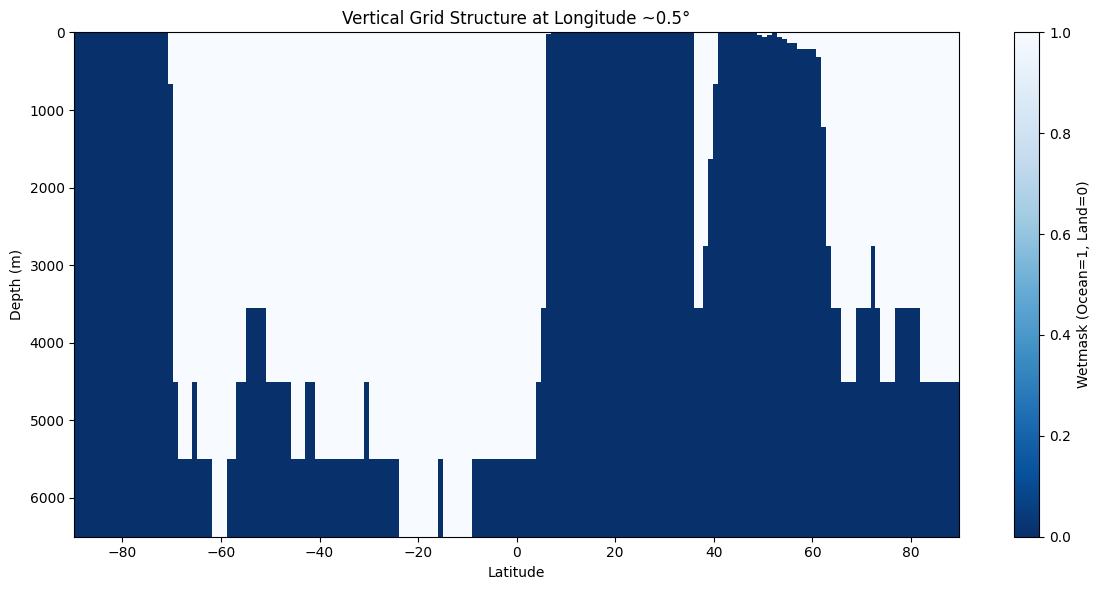

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Choose a longitude slice (e.g., near 180°)
lon_target = 0
lon_idx = np.abs(ds.lon - lon_target).argmin().values

# Extract latitude and vertical coordinates
lat_slice = ds.lat[:, lon_idx].values
depth = ds.lev.values
wetmask_slice = ds.wetmask[:, :, lon_idx].values

# Create meshgrid for plotting
LAT, DEPTH = np.meshgrid(lat_slice, depth)

fig, ax = plt.subplots(figsize=(12, 6))

# Plot wetmask to show grid cells (ocean points)
pcm = ax.pcolormesh(LAT, DEPTH, wetmask_slice, shading="auto", cmap="Blues_r")

ax.set_ylim(ax.get_ylim()[::-1])  # Reverse depth axis
ax.set_xlabel("Latitude")
ax.set_ylabel("Depth (m)")
ax.set_title(f"Vertical Grid Structure at Longitude ~{float(ds.lon[0, lon_idx]):.1f}°")

plt.colorbar(pcm, ax=ax, label="Wetmask (Ocean=1, Land=0)")
plt.tight_layout()
plt.show()